# Personalization:


In [1]:
from cProfile import label

import pandas as pd
import numpy as np
import cv2
from pathlib import Path
import os
import time

In [2]:
root_folder = Path("./personalization/")
text_files = []
video_files = []

for f,folder in enumerate(root_folder.iterdir()):

    if folder.is_dir():

        print(f"\nfolder_name: {folder.name}")
        images_folder = Path(f"{root_folder}/{folder.name}/images")
        images_folder.mkdir(
                parents=True,
                exist_ok=True
            )
        # os.makedirs("images", exist_ok=True)

        for file in folder.iterdir():

            if file.suffix == ".txt" and file.name == f"{folder.name}_position.txt":
                # print("TXT gefunden:", file)
                txt_file = Path(f"{root_folder}/{folder.name}/{folder.name}_position.txt")
                print(f"Text_File: {txt_file.as_posix()}\n")
                text_files.append(txt_file.as_posix())


                

            elif file.suffix == ".mp4":
                # print("MP4 gefunden:", file)
                video_file = Path(f"{root_folder}/{folder.name}/{folder.name}_video.mp4")
                print(f"Video_File: {video_file.as_posix()}\n")
                video_files.append(video_file.as_posix())

print(f"\nText_Files: {text_files}")
print(f"\nVideo_Files: {video_files}")

                


folder_name: __pycache__

folder_name: 03
Text_File: personalization/03/03_position.txt

Video_File: personalization/03/03_video.mp4


folder_name: 04
Video_File: personalization/04/04_video.mp4

Text_File: personalization/04/04_position.txt


folder_name: 02
Video_File: personalization/02/02_video.mp4

Text_File: personalization/02/02_position.txt


folder_name: 01
Text_File: personalization/01/01_position.txt

Video_File: personalization/01/01_video.mp4


Text_Files: ['personalization/03/03_position.txt', 'personalization/04/04_position.txt', 'personalization/02/02_position.txt', 'personalization/01/01_position.txt']

Video_Files: ['personalization/03/03_video.mp4', 'personalization/04/04_video.mp4', 'personalization/02/02_video.mp4', 'personalization/01/01_video.mp4']


In [3]:

for i in range(len(text_files)):

    labels = pd.read_csv(text_files[i], sep=",") 
    # print(labels.head())
    # print(labels.columns)

    labels.columns = labels.columns.str.strip()

    # subject_name = f"{text_files[0].split('/')[1]}"
    subject_name = Path(text_files[i]).parent.name
    print(f"\nsubject_name: {subject_name}\n")

    images_folder = Path(f"./personalization") / subject_name / "images"

    images_folder.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_files[i])

    rows = []
    frame_id = 0
    saved_id = 0
    Steps = 5

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % Steps == 0:

            filename = f"{saved_id:04d}.jpg"

            image_path = images_folder / filename

            cv2.imwrite(str(image_path), frame)




            # cv2.imwrite(
            #     os.path.join(images_folder, filename),
            #     frame
            # )

            rows.append({
            "image_name": filename,
            "x": labels.loc[frame_id, "x"],
            "y": labels.loc[frame_id, "y"]
        })

            saved_id += 1


        frame_id += 1

    cap.release()

    pd.DataFrame(rows).to_csv(
    f"./personalization/{subject_name}/labels.csv", index=False
    )




subject_name: 03


subject_name: 04


subject_name: 02


subject_name: 01



# Random and Constant Error

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np


norm_labels_files = []

for i in range(1, 5):
    file = Path("personalization") / f"0{str(i)}" / "norm_labels.csv"

    if not file.exists():
        print(f"Fehlt: {file.resolve()}")

    else:
        norm_labels_files.append(file.as_posix())

print(f"norm_files:{norm_labels_files}")

df2 = pd.read_csv(norm_labels_files[0])

# print(df2.head())




norm_files:['personalization/01/norm_labels.csv', 'personalization/02/norm_labels.csv', 'personalization/03/norm_labels.csv', 'personalization/04/norm_labels.csv']


In [7]:

for i in range(len(norm_labels_files)):

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: ----------------------------
# -------------------------------------------------------------------

    norm_label = (norm_labels_files[i])
    # print(f"norm_file: {norm_label}")
    # norm_label = Path('./personalization/01/norm_labels.csv')
    df2 = pd.read_csv(norm_label)
    # print(df2.head())



    x_true = df2["x"].values
    y_true = df2["y"].values

    x_const = np.mean(x_true)
    y_const = np.mean(y_true)

    # x_const = 0.5
    # y_const = 0.5

    # print(f"x_const: {x_const}")
    # print(f"y_const: {y_const}")

    pred_x_const = np.full_like(x_true, x_const)
    pred_y_const = np.full_like(y_true, y_const)

    const_errors = np.sqrt(
        (x_true - pred_x_const) ** 2 +
        (y_true - pred_y_const) ** 2
    )


    mae = np.mean(const_errors)
    rmse = np.sqrt(np.mean(const_errors ** 2))
    const_error_pct = np.round(100 * rmse, 5)
    const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    print(f"\nKonstant Baseline: {norm_label}\n")
    # print(f"Constant_Mean_Absolute_Error: {mae}")
    # print(f"Constant_Mean_Squared_Error: {rmse}")
    # print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
    print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


    # -------------------------------------------------------------------
    # ---------------------- Random-Error -------------------------------
    # -------------------------------------------------------------------

    x = df2["x"]
    y = df2["y"]
    x_max = np.max(x)
    x_min = np.min(x)
    y_max = np.max(y)
    y_min = np.min(y)

    # x_max = 1.0
    # y_max = 1.0


    pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
    pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

    random_errors = np.sqrt(
        (x_true - pred_x_random)**2 +
        (y_true - pred_y_random)**2
    )

    mae = np.mean(random_errors)
    rmse = np.sqrt(np.mean(random_errors ** 2))
    random_error_pct = np.round(100 * rmse, 5)
    random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 5)

    # print(f"\nRandom Baseline: {norm_label}\n")
    # print(f"Random_Mean_Absolute_Error: {mae}")
    # print(f"Random_Mean_Squared_Error: {rmse}")
    # print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
    print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} % \n\n")


Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error %: 28.77637 %
Random_Diagonal-Error %: 39.35332 % 



Konstant Baseline: personalization/02/norm_labels.csv

Constant_Diagonal-Error %: 29.30417 %
Random_Diagonal-Error %: 40.24716 % 



Konstant Baseline: personalization/03/norm_labels.csv

Constant_Diagonal-Error %: 28.75691 %
Random_Diagonal-Error %: 40.60045 % 



Konstant Baseline: personalization/04/norm_labels.csv

Constant_Diagonal-Error %: 28.50943 %
Random_Diagonal-Error %: 40.51208 % 




# Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error %: 28.77637 %

Random_Diagonal-Error %: 39.23223 % 



# Konstant Baseline: personalization/02/norm_labels.csv

Constant_Diagonal-Error %: 29.30417 %

Random_Diagonal-Error %: 40.91839 % 



# Konstant Baseline: personalization/03/norm_labels.csv

Constant_Diagonal-Error %: 28.75691 %

Random_Diagonal-Error %: 40.29295 % 


# Konstant Baseline: personalization/04/norm_labels.csv

Constant_Diagonal-Error %: 28.50943 %

Random_Diagonal-Error %: 40.51208 %


## Evaluation: without train

In [8]:
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm



In [9]:
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [10]:
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [11]:

# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
dataset = PersonalGazeDataset(
    root_dir="./personalization/01",
    transform=transform
)

print(f"\nPfade: {dataset.root_dir}\n")

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 498/498 [00:06<00:00, 80.71it/s]


Pfade: personalization/01



In [13]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
        nn.Linear(
            model.fc.in_features,
            512
        ),
        nn.ReLU(),
        nn.Linear(
            512,
            128
        ),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(
            128,
            2
        )
    )



Model: ResNet


In [14]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
checkpoint = torch.load(
    "./models/ResNet_optim-model_norm_subject_1000-200.path",
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [15]:
print(f"\nBaseline-Erorr:")
baseline_mae, baseline_rmse, baseline_diag_pct = diagonal_errors(model, loader, device)
# diag_train_error.append(np.round(train_diag_pct, 4))

print(f"baseline_diag_error={baseline_diag_pct:.4f}%")




Baseline-Erorr:
MAE : 0.2554 	 RMSE: 0.2979 
Diagonal-Error %: 21.0671 %
baseline_diag_error=21.0671%


# Subject: 01
Baseline-Erorr:

MAE : 0.2554 	 RMSE: 0.2979 

Diagonal-Error %: 21.0671 %

baseline_diag_error=21.0671%

# Subject: 02
Baseline-Erorr:

MAE : 0.2543 	 RMSE: 0.2927 

Diagonal-Error %: 20.6937 %

baseline_diag_error=20.6937%

# Subject: 03
Baseline-Erorr:

MAE : 0.2513 	 RMSE: 0.2900 

Diagonal-Error %: 20.5044 %

baseline_diag_error=20.5044%

# Subject: 04
Baseline-Erorr:

MAE : 0.2569 	 RMSE: 0.3003 

Diagonal-Error %: 21.2322 %

baseline_diag_error=21.2322%

## Evaluation: Train: 

In [44]:
# 0: Lib
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm
import time
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


In [17]:
# 1: calss PersonalGazeDataset
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
            # self.root_dir 
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [18]:
# 2: func diagonal_error
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [27]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    return targets, predictions, errors

In [37]:
# Hypoparameter:
batch_size = 64

epochs = 25

patience = 3                   # after 3 Epochen without Optimierung has to stop training

learning_rate = 1e-5    # 1e-4, 1e-5  

session = "01"

best_model_name = "./models/ResNet_best_optim-model_norm_subject_1000-200.path"


In [29]:
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:

dirs = f"personalization/{session}"

pfad = Path(dirs)/"norm_labels.csv"

if not pfad.exists():
    print(f"Fehlt: {pfad.resolve()}")

else:
    csv_pfad = pfad.as_posix()

print(f"csv_pfad: {csv_pfad}")


df3 = pd.read_csv(csv_pfad)
len_df3 = len(df3)
print(f"len(df3):{len_df3}")



train_size = int(np.round(len_df3) * 0.7) 
validat_size = int(np.round(len_df3) * 0.15) 
test_size = int(np.round(len_df3) * 0.15)

# print(f"\n train_size: {train_size}" 
#       f"\n validat_size: {validat_size}" 
#       f"\n test_size: {test_size} \n"
# )

sum_tvt = train_size + validat_size + test_size

# print(f"Summe Tr_Val_Tes: {sum_tvt}")

if len_df3 - sum_tvt == 2:
    validat_size += 1
    test_size += 1

elif len_df3 - sum_tvt == 1:
    train_size += 1

elif len_df3 - sum_tvt == -1:
    train_size -= 1


print(f"\n train_size: {train_size}" 
      f"\n validat_size: {validat_size}" 
      f"\n test_size: {test_size} \n"
)

# print(f"validat_size: {validat_size}")
# print(f"test_size: {test_size}")
sum_tvt = train_size + validat_size + test_size
print(f"Summe : {sum_tvt}")

print(f"{ int(len_df3) == int(sum_tvt) }")


csv_pfad: personalization/01/norm_labels.csv
len(df3):498

 train_size: 348
 validat_size: 75
 test_size: 75 

Summe : 498
True


In [31]:
# dataset = PersonalGazeDataset(
#     root_dir=root_dirs,
#     transform=transform
# )

train_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=train_size,
)


validat_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
    dataset_size=validat_size,
)


test_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=test_size,
)


print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")




# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)




100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:01<00:00, 59.44it/s]


 len(train_dataset): 348
 len(validat_dataset):  75
 len(test_dataset): 75


In [22]:
## Test:
# batch = next(iter(train_loader))

# images, targets = batch

# print(images.shape)
# print(targets.shape)

In [32]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    # GaussianActivation(sigma=1.0),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    nn.Sigmoid()
)

active_func = 'Sigmoid'


Model: ResNet


In [33]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
# checkpoint = torch.load(
#     "./models/ResNet_optim-model_norm_subject_1000-200.path",
#     map_location=device
# )

checkpoint = torch.load(
    best_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [34]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()


for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True
    
    model_layer4 = any(
    param.requires_grad
    for param in model.layer4.parameters()
)

    only_FC = not model_layer4
    

for param in model.fc.parameters():
    param.requires_grad=True

    model_fc = any(
    param.requires_grad
    for param in model.layer4.parameters()
)
    


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)

# if globals().get("bas_const_err") is None:
#     bas_const_err = 27.245

# if globals().get("bas_rand_err") is None:
#     bas_rand_err = 38.961
print(f"only_FC: {only_FC} \t model_layer4: {model_layer4} \t model_FC: {model_fc}")

only_FC: False 	 model_layer4: True 	 model_FC: True


In [40]:

model_output = './models/personal'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

train_start = time.perf_counter()
print(f"\nSession: {session}\n")

best_error = None
diag_val_error, diag_train_error = [], []


t = 0                      # Number Epochen without Optimierung
e = 0                      # Number Epochen with Optimierung

# patience = 4               # after 4 Epochen without Optimierung has to stop training

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()
    
    print(f"\n train_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\n valid_error:")
    valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
    diag_val_error.append(np.round(valid_diag_pct, 4))

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------
    
    if best_error is None or valid_diag_pct < best_error:
    
        # find an improvement
        best_error = valid_diag_pct
        t = 0
        e += 1
    
        print(
            f"Validation-Diagonal-Error: {valid_diag_pct:.4f}% | "
            f"Improvment: {e}"
        )
    
        # save the better Modell
        torch.save(
            model.state_dict(),
            f"./models/personal/{model_name}_best_model_lr({learning_rate})_"
            f"session({session}).path"
        )
    
    else:
    
        # without imporovement
        t += 1
    
        print(
            f"Patience: {t}/{patience}"
        )
    
        if t >= patience:
            print(
                f"\nEarly Stopping after {epoch + 1} Epochen."
            )
            print(
                f"Imporovments totally: {e}"
            )
            break
    
    

    epoch_end = time.perf_counter()

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"validation_diag_error={valid_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% \n"
    )

    torch.save(
            model.state_dict(),
            f"./models/personal/{model_name}_last_model_lr({learning_rate})_"
            f"session({session}).path"
        )


train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"min Epochs: {e}\n")
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")


# end_time = time.perf_counter()
# elapsed_time = end_time - start_time
# print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
# print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


Session: 01



Epoch 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:19<00:00,  3.20s/it, loss=0.0307]



 train_error:
MAE : 0.2327 	 RMSE: 0.2708 
Diagonal-Error %: 19.1456 %

 valid_error:
MAE : 0.2488 	 RMSE: 0.2857 
Diagonal-Error %: 20.2033 %
Validiation-Diagonal-Error: 20.2033% | Improvment: 1

[20:27:51] Epoch 1: 35.81 Sekunden | Running_loss: 0.037 | validation_diag_error=20.2033% | train_diag_error=19.1456% 



Epoch 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:21<00:00,  3.64s/it, loss=0.0339]



 train_error:
MAE : 0.2280 	 RMSE: 0.2659 
Diagonal-Error %: 18.8037 %

 valid_error:
MAE : 0.2450 	 RMSE: 0.2816 
Diagonal-Error %: 19.9123 %
Validiation-Diagonal-Error: 19.9123% | Improvment: 2

[20:28:32] Epoch 2: 40.76 Sekunden | Running_loss: 0.036 | validation_diag_error=19.9123% | train_diag_error=18.8037% 



...


 train_error:
MAE : 0.1090 	 RMSE: 0.1392 
Diagonal-Error %: 9.8419 %

 valid_error:
MAE : 0.1433 	 RMSE: 0.1785 
Diagonal-Error %: 12.6202 %
Validiation-Diagonal-Error: 12.6202% | Improvment: 23

[20:43:15] Epoch 23: 42.05 Sekunden | Running_loss: 0.011 | validation_diag_error=12.6202% | train_diag_error=9.8419% 



Epoch 24: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:23<00:00,  3.91s/it, loss=0.0127]



 train_error:
MAE : 0.1043 	 RMSE: 0.1329 
Diagonal-Error %: 9.3960 %

 valid_error:
MAE : 0.1385 	 RMSE: 0.1732 
Diagonal-Error %: 12.2476 %
Validiation-Diagonal-Error: 12.2476% | Improvment: 24

[20:43:59] Epoch 24: 44.31 Sekunden | Running_loss: 0.010 | validation_diag_error=12.2476% | train_diag_error=9.3960% 



Epoch 25: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:22<00:00,  3.75s/it, loss=0.00834]



 train_error:
MAE : 0.0984 	 RMSE: 0.1259 
Diagonal-Error %: 8.9002 %

 valid_error:
MAE : 0.1335 	 RMSE: 0.1681 
Diagonal-Error %: 11.8849 %
Validiation-Diagonal-Error: 11.8849% | Improvment: 25

[20:44:41] Epoch 25: 41.59 Sekunden | Running_loss: 0.009 | validation_diag_error=11.8849% | train_diag_error=8.9002% 

min Epochs: 25


totll running-tiems (s): 1045.95 Sekunden
totll running-tiems (min): 17.43 Minuten





 Diagonal-Train-Error: [19.1456 18.8037 18.4562 18.1033 17.7315 17.3435 16.9652 16.5551 16.1547
 15.7811 15.3571 14.9497 14.5026 14.0562 13.5938 13.1504 12.7026 12.1903
 11.7223 11.2544 10.7544 10.2756  9.8419  9.396   8.9002]

 Diagonal-Test-Error: [20.2033 19.9123 19.6152 19.3138 18.9902 18.6455 18.3239 17.9827 17.6471
 17.3117 16.9729 16.6494 16.308  15.9486 15.5888 15.2333 14.8809 14.495
 14.1189 13.7339 13.3508 12.9585 12.6202 12.2476 11.8849]


 Diagonal-Train-Error-Max: 19.1456 	 Diagonal-Train-Error-Min: 8.9002	
 Diagonal-Test-Error-Max: 20.2033	 Diagonal-Test-Error-Min: 11.8849	 max_needed_epochs: 27



Minimum Test Error:
Epoch:           25
Test Error:      11.8849%
Train Error:     8.9002%
Constant Error:  28.7760%
Random Error:    39.2320%



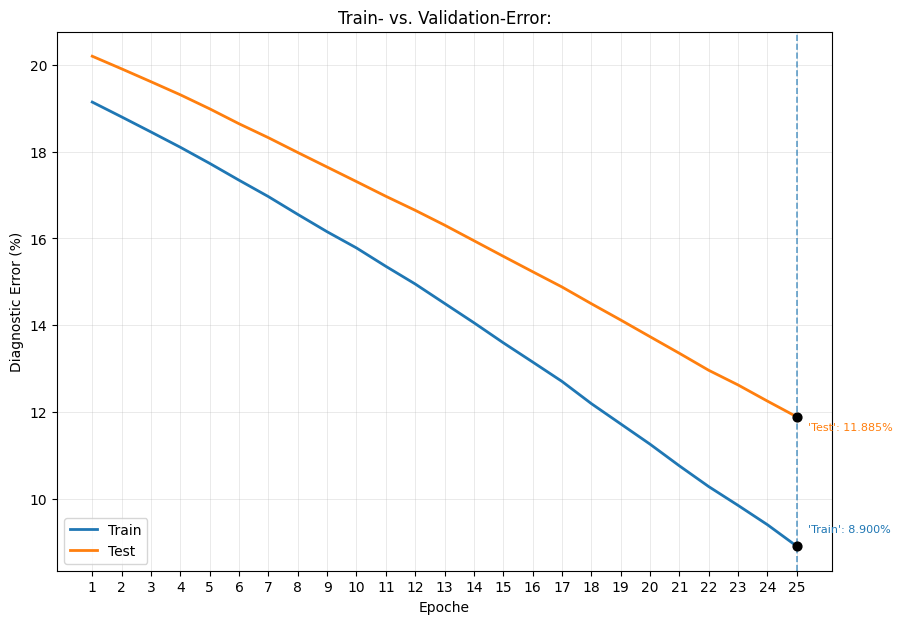

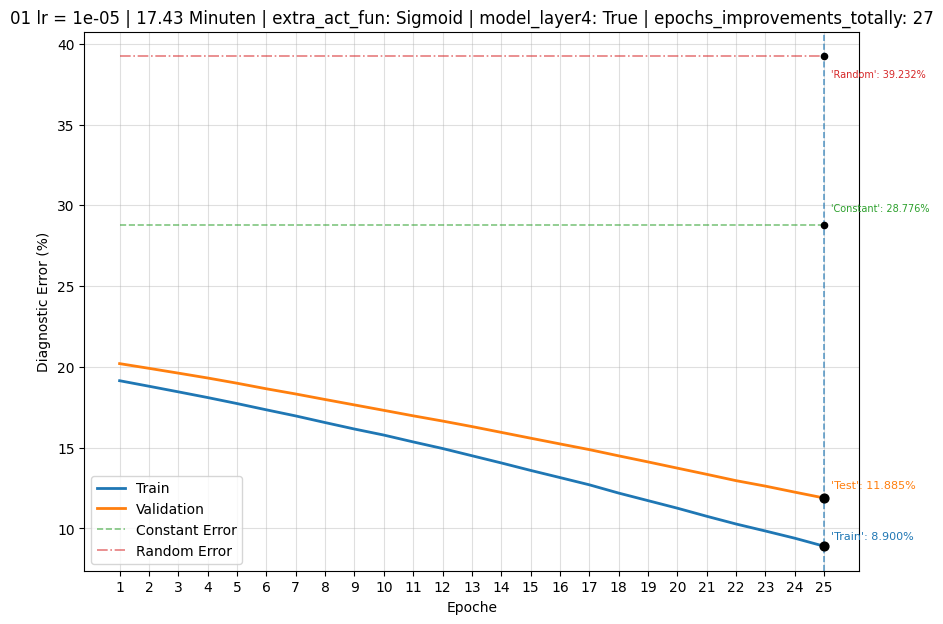

In [45]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_val_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_val_error)}\t Diagonal-Test-Error-Min: {np.min(diag_val_error)}\t max_needed_epochs: {e+2}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")

# Session: 01
if globals().get("bas_const_err") is None:
    bas_const_err = 28.776

if globals().get("bas_rand_err") is None:
    bas_rand_err = 39.232


# Curven:

# Minimum Test Error bestimmen
min_val_error = min(diag_val_error)
min_val_epoch = diag_val_error.index(min_val_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_val_epoch - 1]
val_at_min = diag_val_error[min_val_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
val_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_val_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Validation Error
plt.plot(epochs, diag_val_error, label="Test", linewidth=2, color=val_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=val_color,
    fontsize=8,
)


plt.title("Train- vs. Validation-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Validation Error
plt.plot(
    epochs,
    diag_val_error,
    label="Validation",
    linewidth=2,
    color=val_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_val_epoch}")
print(f"Validation Error:      {val_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_val_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=val_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_val_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_val_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{session} "
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"model_layer4: {model_layer4} | "
    f"epochs_improvements_totally: {e + 2}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results/personal", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/personal/diag_error_{session}_{learning_rate}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ---------- Evaluation ----------

In [48]:
# ---------- Evaluation ----------

saved_model_name = "models/personal/ResNet_best_model_lr(1e-05)_session(01).path"

checkpoint = torch.load(
    saved_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()

print(f"Test:\n")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error={test_diag_pct:.4f}% "
    )

targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test:

MAE : 0.1341 	 RMSE: 0.1672 
Diagonal-Error %: 11.8241 %
test_diag_error=11.8241% 


# Test:

MAE : 0.1341 	 RMSE: 0.1672 

Diagonal-Error %: 11.8241 %

test_diag_error=11.8241%

In [19]:
# 01:
print(f"the results for Session: {session}")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01


Diagonal_train_error: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden
totll running-tiems (min): 5.19 Minuten



# the results for Session: 01
## only FC and without layer 4

Diagonal_train_error01: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error01: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden

totll running-tiems (min): 5.19 Minuten

In [24]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden
totll running-tiems (min): 4.88 Minuten



# the results for Session: 02

## only FC and without layer 4


Diagonal_train_error02: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error02: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden

totll running-tiems (min): 4.88 Minuten

In [29]:
# 03:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 03

only FC and without layer 4



Diagonal_train_error: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden
totll running-tiems (min): 5.62 Minuten



## the results for Session: 03

# only FC and without layer 4


Diagonal_train_error03: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error03: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden

totll running-tiems (min): 5.62 Minuten


In [51]:
# 04:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 04

only FC and without layer 4



Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden
totll running-tiems (min): 5.57 Minuten



# the results for Session: 04

## only FC and without layer 4


Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden

totll running-tiems (min): 5.57 Minuten


# ==================== Optimal =============================

In [56]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [19.4212 17.7688 16.9373 16.432  15.9572 15.5047 15.0849 14.7342 14.4432
 14.2265 14.0141 13.781  13.5563 13.348  13.1246 12.9289 12.7407 12.5674
 12.3858 12.2026]


Diagonal_test_error: [20.9319 17.7764 15.8419 14.8768 14.4095 14.1325 14.111  14.2164 14.2938
 14.2955 14.1694 13.848  13.4551 13.3329 13.005  12.886  12.8297 12.8031
 12.6214 12.4136]

 epochs: 20, 	 best_Error: 0.17555457971299732
 best_test_error: 12.4136%, 	max_test_Error: 20.9319%

totll running-tiems (s): 574.36 Sekunden
totll running-tiems (min): 9.57 Minuten



In [62]:
# 01:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

only FC and without layer 4



Diagonal_train_error: [15.3648 15.1013 15.1603 14.678  14.3885 14.2098 14.0774 13.9202 13.78
 13.657  13.5354 13.4318 13.3666 13.243  13.1577 13.0428 12.9579 12.9177
 12.7877 12.7263]


Diagonal_test_error: [16.7358 16.2906 16.3221 15.8886 15.7614 15.5712 15.2743 15.2488 15.1827
 15.0881 14.9273 14.8744 14.7402 14.6438 14.6689 14.6622 14.6104 14.5191
 14.4285 14.46  ]

 epochs: 20, 	 best_Error: 0.2040497107098068
 best_test_error: 14.4285%, 	max_test_Error: 16.7358%

totll running-tiems (s): 788.43 Sekunden
totll running-tiems (min): 13.14 Minuten



In [65]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 



Diagonal_train_error: [11.3647 10.2059  9.183   8.3242  7.5884  7.1476  6.4918  5.9299  5.6028
  5.1456  4.8113  4.533   4.2175  4.0028  3.7746  3.6418  3.4019  3.2304
  3.0697  3.1854]


Diagonal_test_error: [13.5827 12.993  12.4911 12.0546 11.8701 11.8472 11.48   10.8924 10.5413
 10.593  10.3502 10.3507 10.138  10.1412 10.1741 10.1195 10.0583  9.904
  9.8323  9.8302]

 epochs: 20, 	 best_Error: 0.1390205620095576
 best_test_error: 9.8302%, 	max_test_Error: 13.5827%

totll running-tiems (s): 1350.90 Sekunden
totll running-tiems (min): 22.51 Minuten



In [12]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 and Sigmoid \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 and Sigmoid 



Diagonal_train_error: [21.2963 20.4879 19.7773 19.1741 18.6438 18.159  17.7288 17.3245 16.9491
 16.5914 16.2423 15.8723 15.5279 15.1753 14.8057 14.446  14.0653 13.6825
 13.2886 12.9093]


Diagonal_test_error: [22.5788 21.8181 21.181  20.6503 20.1906 19.7427 19.3522 18.9706 18.6466
 18.3322 18.0399 17.7275 17.4513 17.1487 16.8487 16.573  16.2839 16.0158
 15.7229 15.4488]

 epochs: 20, 	 best_Error: 0.2184786646452124
 best_test_error: 15.4488%, 	max_test_Error: 22.5788%

totll running-tiems (s): 1438.26 Sekunden
totll running-tiems (min): 23.97 Minuten

